In [21]:
import io
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
sns.set(style="whitegrid")

### Load Data
- We have multiple tickers in our dataset, but for this analysis, we will focus on the S&P 500 (ES) and Nasdaq 100 (NQ) futures contracts. We will read the data from a CSV file and filter it accordingly.
- We also create target columns that represent the sum of the 'target' variable over the next 2 to 19 days. This will help us analyze the future performance of these futures contracts.
- We also remove weekly features since they are empty and won't be used in this project

In [22]:
data = pd.read_csv("../daily_futures_data.csv", low_memory=False)
data = data.drop(columns=[
    'Unnamed: 0',
    'datetime',
    'donchian_channel_10_W_W_donchian_10',
    'moving_avg_diff_2_8_W_W_ma_difference_2_8_2',
    'moving_avg_diff_5_50_W_W_ma_difference_5_50_5',
    'turtle_W_donchian_4',
    'turtle_W_donchian_4_position'
    ])
data.rename(columns={'index':'date'}, inplace=True)
tickers = ['ES', 'NQ']
data = data[data['ticker'].isin(tickers)] # Only use S&P, Nasdaq, Dow, Russell
for i in range(2, 20):
    data["target_close_{}d".format(i)] = data['target'].rolling(window=i).sum().shift(-i)
data.reset_index(drop=True, inplace=True)

### Quick overview at the data
- Missing values analysis
    - Data contains no missing values. If there were missing values, we would consider removal instead of imputation (avg, median, etc) since the data is time-series based and the price movements are sequential.
- Contain data sample view
- Statistical summary of the data

In [23]:
overview_buffer = io.StringIO()
data.info(buf=overview_buffer)
print("Dataset info:\n", overview_buffer.getvalue())
print(f"Shape: {data.shape}")
display(data.head())
numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = data.select_dtypes(include=["object", "category"]).columns.tolist()
display(data[numeric_columns].describe().transpose())
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Dataset info:
 <class 'pandas.core.frame.DataFrame'>
RangeIndex: 13007 entries, 0 to 13006
Data columns (total 76 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                13007 non-null  object 
 1   open                                                13007 non-null  float64
 2   high                                                13007 non-null  float64
 3   low                                                 13007 non-null  float64
 4   close                                               13007 non-null  float64
 5   volume                                              13007 non-null  int64  
 6   target                                              13007 non-null  float64
 7   bollinger_band_D_bollinger_80_1.0                   13007 non-null  float64
 8   donchian_channel_10_D_D_donchian_10                 13007 non

,date,open,high,low,close,volume,target,bollinger_band_D_bollinger_80_1.0,donchian_channel_10_D_D_donchian_10,donchian_channel_10_D_D_donchian_10_position,...,target_close_10d,target_close_11d,target_close_12d,target_close_13d,target_close_14d,target_close_15d,target_close_16d,target_close_17d,target_close_18d,target_close_19d
0,2000-01-03 00:00:00+00:00,1489.00,1496.00,1452.25,1466.8,61938,-0.015022,0.0,0.0,0,...,0.009327,0.003560,0.006110,-0.004642,-0.005708,-0.035161,-0.029789,-0.031272,-0.033185,-0.065231
1,2000-01-04 00:00:00+00:00,1467.00,1468.75,1409.50,1411.8,64048,-0.038354,0.0,1.0,0,...,0.041914,0.044464,0.033712,0.032646,0.003193,0.008565,0.007082,0.005169,-0.026877,-0.001028
2,2000-01-05 00:00:00+00:00,1411.50,1427.25,1385.00,1413.5,73121,0.001416,0.0,1.0,0,...,0.043048,0.032296,0.031230,0.001777,0.007149,0.005666,0.003753,-0.028293,-0.002444,0.007522
3,2000-01-06 00:00:00+00:00,1411.00,1426.25,1395.75,1404.0,67883,-0.004973,0.0,1.0,0,...,0.037269,0.036204,0.006751,0.012122,0.010640,0.008727,-0.023319,0.002529,0.012495,0.011613
4,2000-01-07 00:00:00+00:00,1403.75,1461.50,1397.50,1460.5,60545,0.039632,0.0,1.0,0,...,-0.003428,-0.032881,-0.027509,-0.028992,-0.030905,-0.062951,-0.037102,-0.027136,-0.028019,-0.016955


,count,mean,std,min,25%,50%,75%,max
open,13007.0,3965.402668,4445.735506,674.750000,1387.000000,2092.250000,4.381500e+03,2.471775e+04
high,13007.0,4001.102210,4485.762366,694.750000,1400.500000,2103.250000,4.414875e+03,2.488800e+04
low,13007.0,3927.997636,4403.641374,665.750000,1372.500000,2078.750000,4.346000e+03,2.465500e+04
close,13007.0,3967.111886,4448.604598,676.000000,1388.000000,2093.500000,4.382500e+03,2.486625e+04
volume,13007.0,880674.708388,795752.532719,0.000000,271335.000000,568859.000000,1.385617e+06,6.285917e+06
target,13007.0,0.000241,0.014429,-0.117680,-0.005399,0.000760,6.725092e-03,1.177114e-01
bollinger_band_D_bollinger_80_1.0,13007.0,0.306835,0.850162,-1.000000,-1.000000,1.000000,1.000000e+00,1.000000e+00
donchian_channel_10_D_D_donchian_10,13007.0,0.222419,0.974910,-1.000000,-1.000000,1.000000,1.000000e+00,1.000000e+00
donchian_channel_10_W_W_donchian_10_position,13007.0,0.999846,0.012400,0.000000,1.000000,1.000000,1.000000e+00,1.000000e+00
donchian_channel_160_D_D_donchian_160,13007.0,0.394480,0.918856,-1.000000,-1.000000,1.000000,1.000000e+00,1.000000e+00


Numeric columns: ['open', 'high', 'low', 'close', 'volume', 'target', 'bollinger_band_D_bollinger_80_1.0', 'donchian_channel_10_D_D_donchian_10', 'donchian_channel_10_W_W_donchian_10_position', 'donchian_channel_160_D_D_donchian_160', 'donchian_channel_20_W_W_donchian_20', 'donchian_channel_20_W_W_donchian_20_position', 'donchian_channel_4_W_W_donchian_4', 'moving_avg_diff_10_100_D_D_ma_difference_10_100_10', 'moving_avg_diff_10_100_W_W_ma_difference_10_100_10', 'moving_avg_diff_16_32_D_D_ma_difference_16_32_16', 'moving_avg_diff_16_32_W_W_ma_difference_16_32_16', 'moving_avg_diff_16_64_D_D_ma_difference_16_64_16', 'moving_avg_diff_16_64_W_W_ma_difference_16_64_16', 'moving_avg_diff_2_4_D_D_ma_difference_2_4_2', 'moving_avg_diff_2_4_W_W_ma_difference_2_4_2', 'moving_avg_diff_2_8_D_D_ma_difference_2_8_2', 'moving_avg_diff_32_128_D_D_ma_difference_32_128_32', 'moving_avg_diff_32_128_W_W_ma_difference_32_128_32', 'moving_avg_diff_32_64_D_D_ma_difference_32_64_32', 'moving_avg_diff_32_64_W

### Missing Value Analysis
- The dataset contains no missing values.
- The missing value below is because the rolling sum for target columns at the end of the dataset cannot be computed due to insufficient future data points.

In [24]:
missing_summary = data.isna().sum().sort_values(ascending=False)
missing_pct = data.isna().mean().sort_values(ascending=False) * 100
missing_df = pd.DataFrame({"missing_count": missing_summary, "missing_pct": missing_pct})
duplicated_rows = data.duplicated().sum()
print(f"Total duplicated rows: {duplicated_rows}")
display(missing_df[missing_df["missing_count"] > 0])


Total duplicated rows: 0


,missing_count,missing_pct
target_close_19d,19,0.146075
target_close_18d,18,0.138387
target_close_17d,17,0.130699
target_close_16d,16,0.123011
target_close_15d,15,0.115323
target_close_14d,14,0.107634
target_close_13d,13,0.099946
target_close_12d,12,0.092258
target_close_11d,11,0.084570
target_close_10d,10,0.076882


### Feature Type Overview
- The dataset contains a mix of numerical and categorical features.
- Numerical features include price-related columns (e.g., open, high, low, close) and technical indicators (e.g., moving averages, RSI).
- Categorical features include the ticker symbol and any other non-numeric columns.

In [25]:
print(f"Numeric feature count: {len(numeric_columns)}")
print(f"Categorical feature count: {len(categorical_columns)}")
print("First 10 numeric columns:", numeric_columns[:10])
print("Categorical columns:", categorical_columns)


Numeric feature count: 54
Categorical feature count: 22
First 10 numeric columns: ['open', 'high', 'low', 'close', 'volume', 'target', 'bollinger_band_D_bollinger_80_1.0', 'donchian_channel_10_D_D_donchian_10', 'donchian_channel_10_W_W_donchian_10_position', 'donchian_channel_160_D_D_donchian_160']
Categorical columns: ['date', 'donchian_channel_10_D_D_donchian_10_position', 'donchian_channel_160_D_D_donchian_160_position', 'donchian_channel_20_D_D_donchian_20', 'donchian_channel_20_D_D_donchian_20_position', 'donchian_channel_40_D_D_donchian_40', 'donchian_channel_40_D_D_donchian_40_position', 'donchian_channel_4_W_W_donchian_4_position', 'donchian_channel_50_W_W_donchian_50', 'donchian_channel_50_W_W_donchian_50_position', 'donchian_channel_5_D_D_donchian_5', 'donchian_channel_5_D_D_donchian_5_position', 'donchian_channel_80_D_D_donchian_80', 'donchian_channel_80_D_D_donchian_80_position', 'moving_avg_diff_8_16_W_W_ma_difference_8_16_8', 'moving_avg_diff_8_32_D_D_ma_difference_8_32_8

### Box plots for numeric features

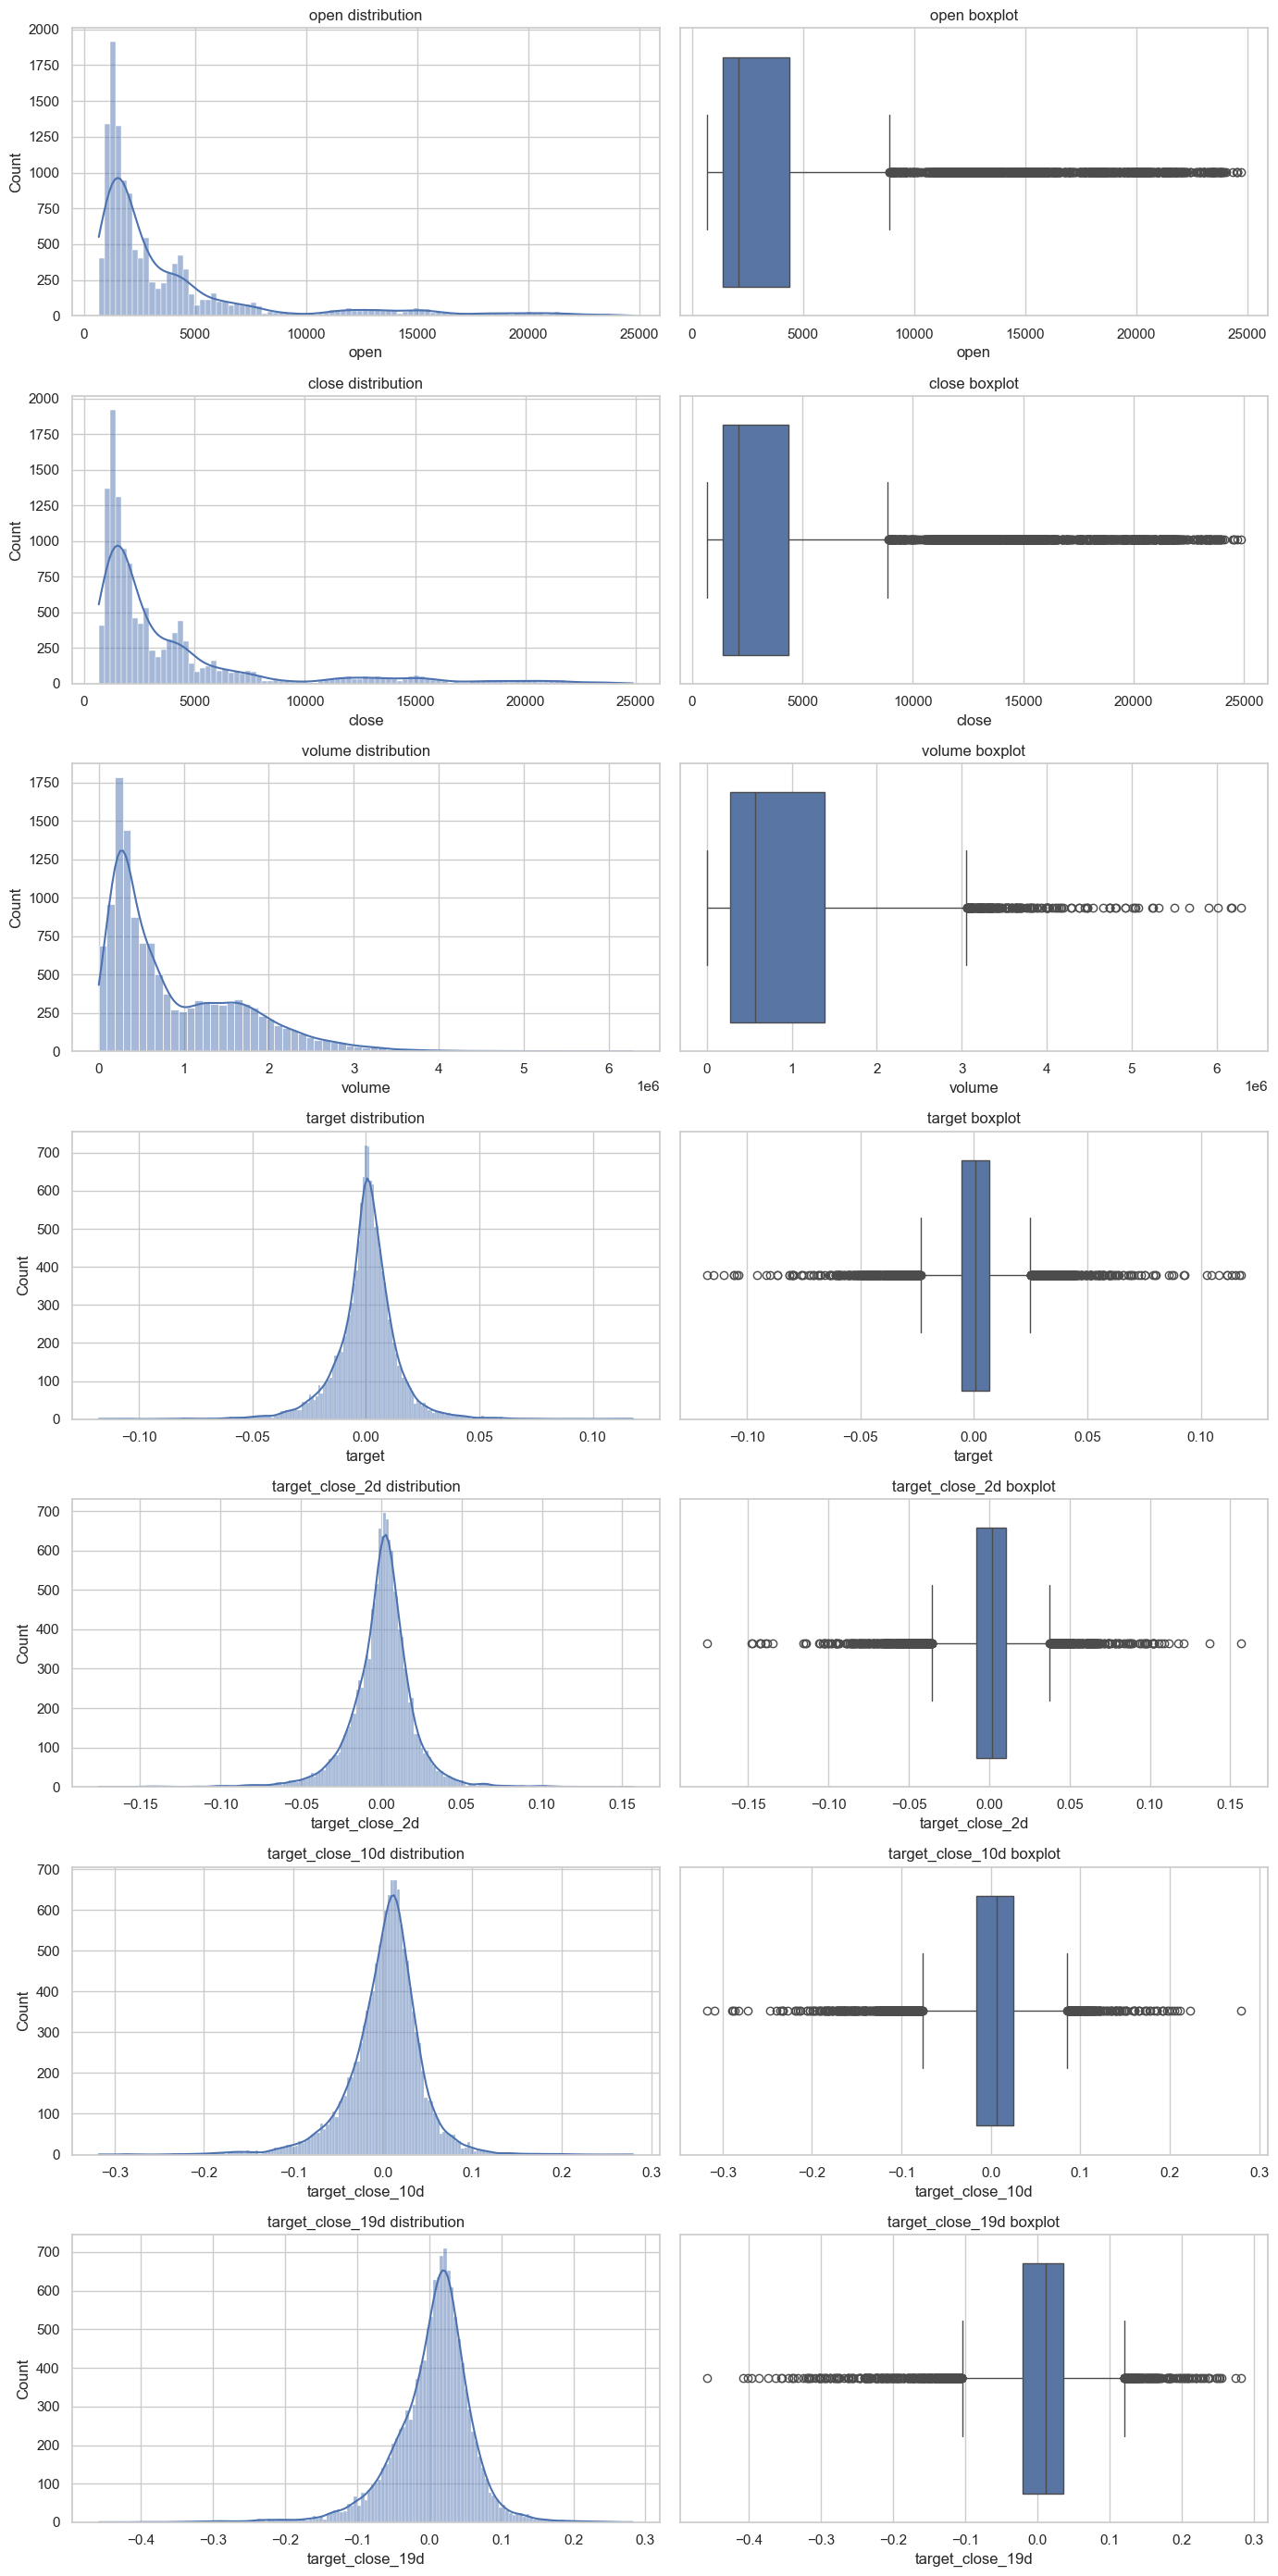

In [26]:
key_numeric = [col for col in ["open", "close", "volume", "target", 'target_close_2d', 'target_close_10d', 'target_close_19d'] if col in numeric_columns]
fig, axes = plt.subplots(len(key_numeric), 2, figsize=(14, 4 * len(key_numeric)))
for idx, column in enumerate(key_numeric):
    sns.histplot(data[column].dropna(), kde=True, ax=axes[idx, 0])
    axes[idx, 0].set_title(f"{column} distribution")
    sns.boxplot(x=data[column].dropna(), ax=axes[idx, 1])
    axes[idx, 1].set_title(f"{column} boxplot")
plt.tight_layout()


### Ticker distribution
- 2 equally represented tickers: ES and NQ

In [27]:
plt.figure(figsize=(12, 6))
print(ticker_counts := data['ticker'].value_counts().sort_values(ascending=False))

ticker
NQ    6504
ES    6503
Name: count, dtype: int64


<Figure size 1200x600 with 0 Axes>

### Bull vs Bear Distribution
- The target variable shows a balanced distribution between bull (1) and bear (0) markets

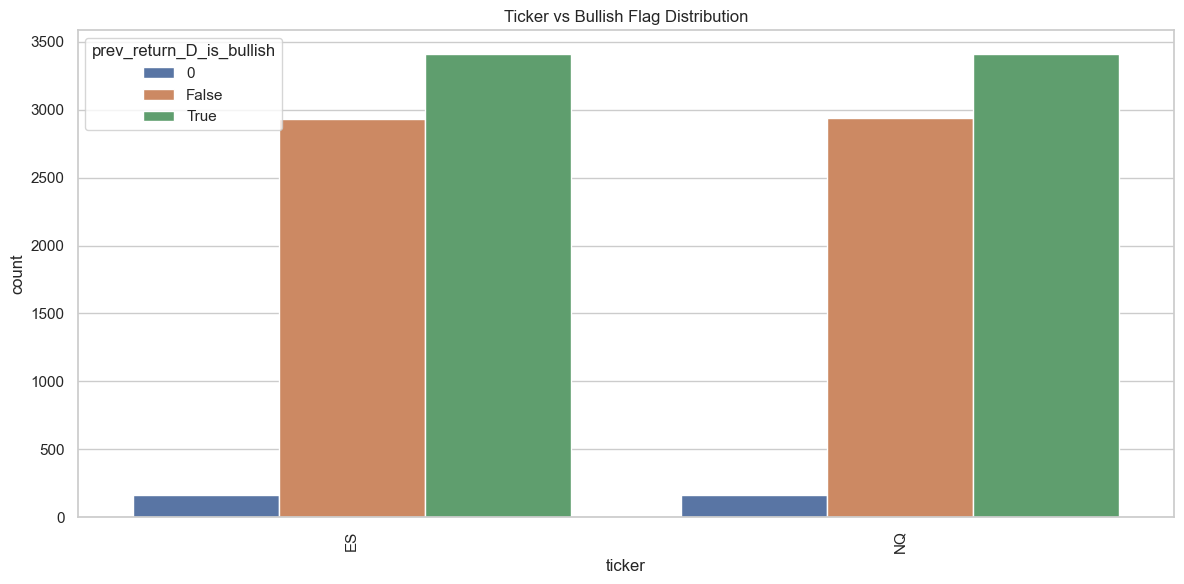

In [28]:
# Bullish flag distribution per ticker
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='ticker', hue='prev_return_D_is_bullish')
plt.xticks(rotation=90)
plt.title('Ticker vs Bullish Flag Distribution')
plt.tight_layout()


### Spearman Correlation Heatmap between Numerical Features
- The heatmap reveals strong correlations between certain technical indicators and price movements, indicating their potential predictive power for forecasting future price trends.

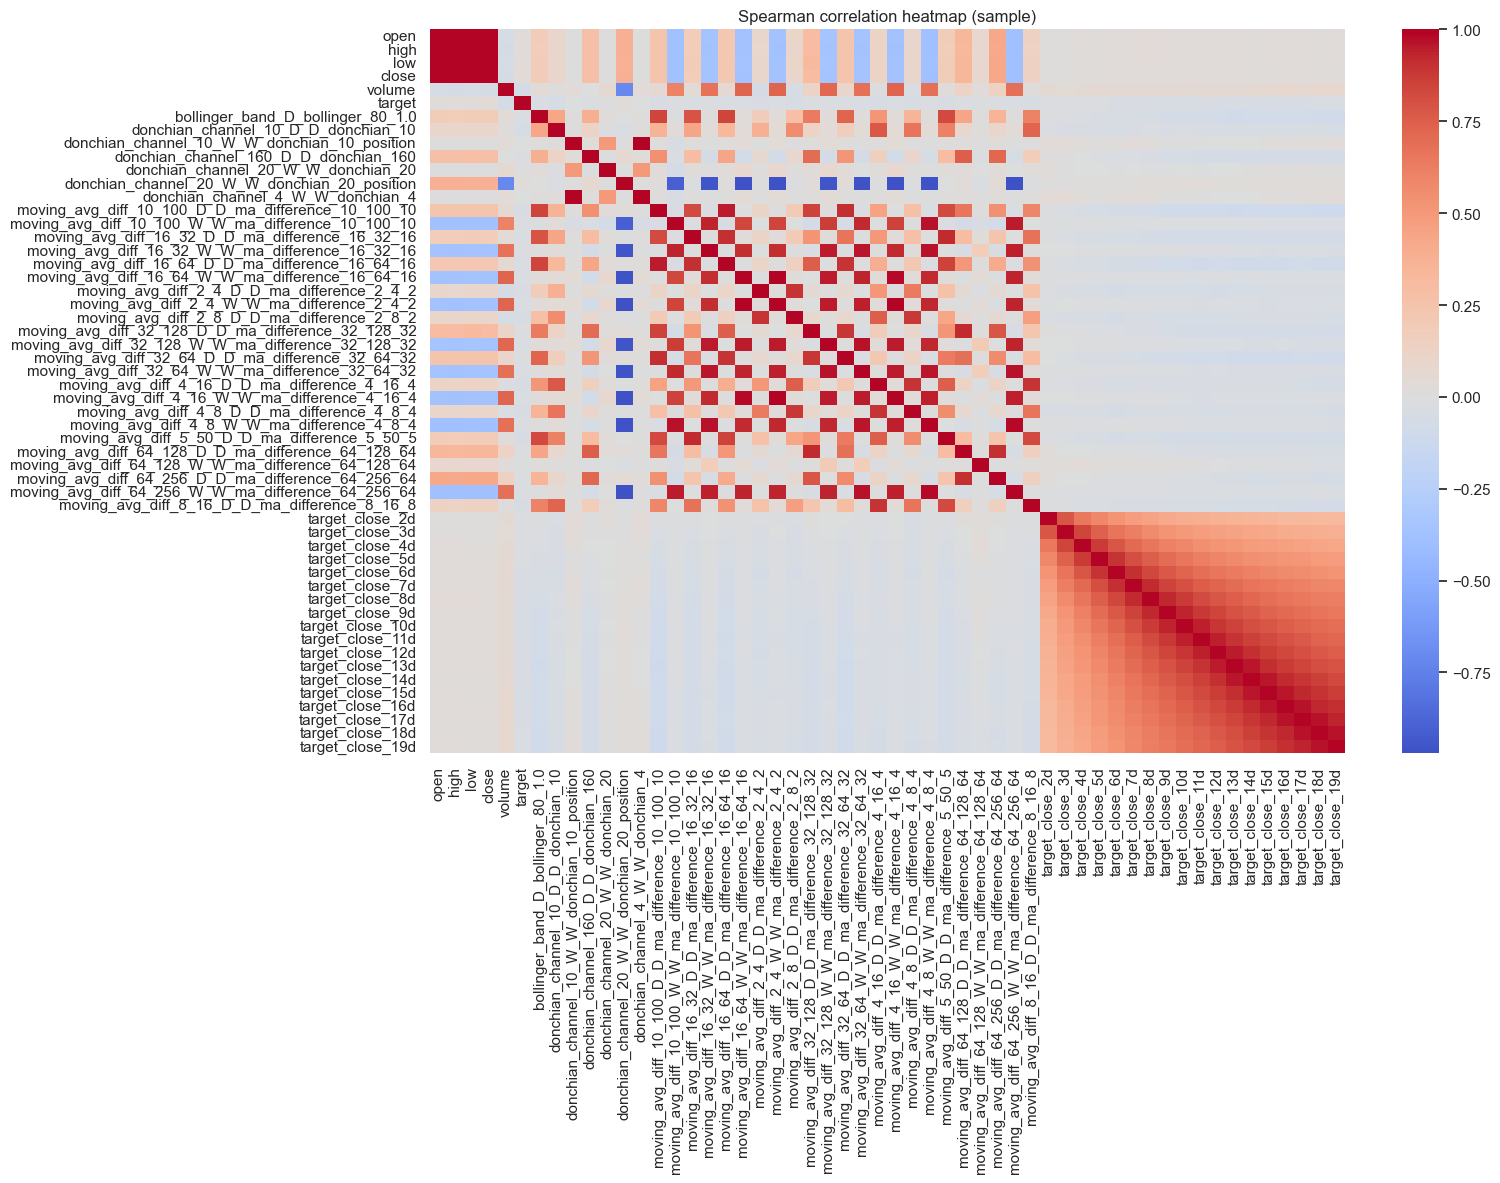

In [29]:
sample_numeric = data[numeric_columns].sample(n=min(5000, len(data)), random_state=42)
corr_matrix = sample_numeric.corr(method='spearman')
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Spearman correlation heatmap (sample)')
plt.tight_layout()

Top 10 highly correlated feature pairs

In [30]:
# Identify high correlation pairs
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, idx, value)
    for col in upper_triangle.columns
    for idx, value in upper_triangle[col].dropna().items()
    if abs(value) > 0.8
]
print("Highly correlated pairs (abs(corr) > 0.8):", len(high_corr_pairs))
for feature_a, feature_b, corr_value in high_corr_pairs[:10]:
    print(f"{feature_a} vs {feature_b}: {corr_value:.2f}")


Highly correlated pairs (abs(corr) > 0.8): 120
high vs open: 1.00
low vs open: 1.00
low vs high: 1.00
close vs open: 1.00
close vs high: 1.00
close vs low: 1.00
donchian_channel_4_W_W_donchian_4 vs donchian_channel_10_W_W_donchian_10_position: 1.00
moving_avg_diff_10_100_D_D_ma_difference_10_100_10 vs bollinger_band_D_bollinger_80_1.0: 0.84
moving_avg_diff_10_100_W_W_ma_difference_10_100_10 vs donchian_channel_20_W_W_donchian_20_position: -0.91
moving_avg_diff_16_32_D_D_ma_difference_16_32_16 vs moving_avg_diff_10_100_D_D_ma_difference_10_100_10: 0.82


### Correlation Analysis
**Diagonal Distribution**:
- ES spreads out more than NQ
- All price-related variables (open, high, low, close) have similar bell-shaped distributions, which make sense since they are all measuring price.
- Target distribution: centered around 0, show balanced positive/negative returns
**Scatterplots**:
- All pairwise between price-related variables (open, high, low, close) show strong linear relationships, indicating that these prices move together.
- Pairwise scatterplots involving the target variable show more dispersion, indicating that while there is some relationship between price movements and future returns, it is not as strong or linear as the relationships among the price variable themselves (that's where technical indicators come in).

Text(0.5, 1.02, 'Pairwise relationships across selected tickers')

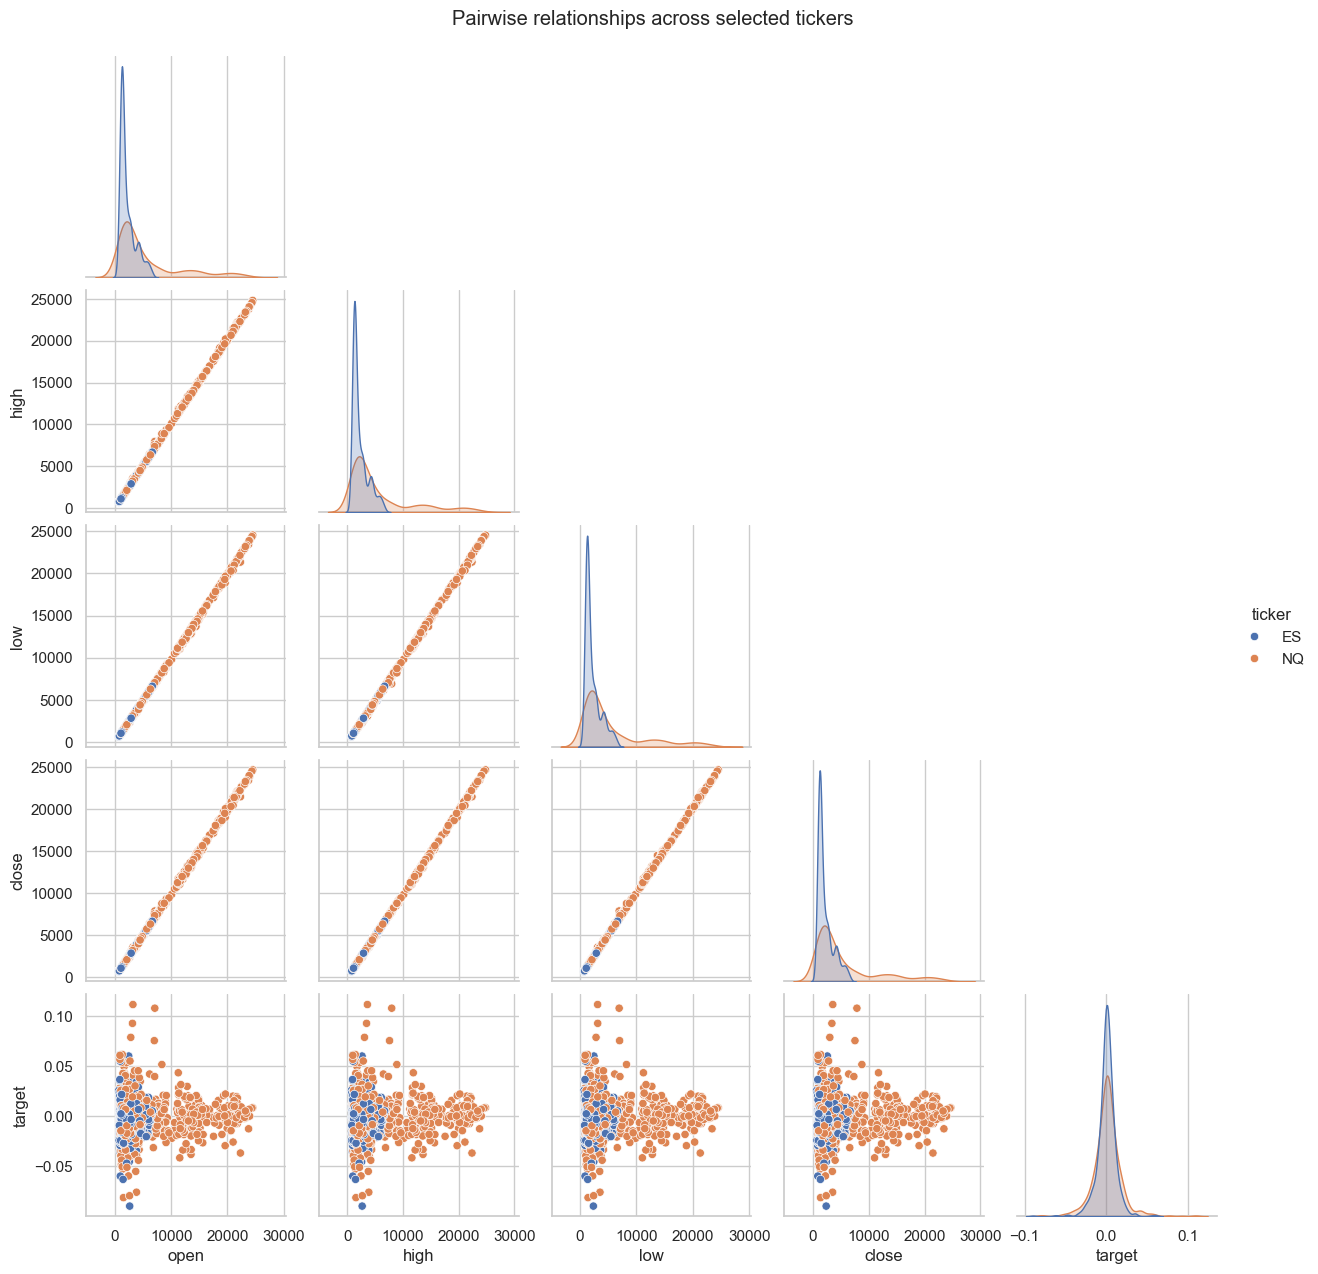

In [31]:
# Visualize pair plot for a sample subset of tickers to inspect relationships
subset_tickers = data['ticker'].value_counts().index[:3]
subset = data[data['ticker'].isin(subset_tickers)]
plot_cols = [col for col in ["open", "high", "low", "close", "target"] if col in subset.columns]
pairplot_sample = subset.sample(n=min(2000, len(subset)), random_state=42)
sns.pairplot(pairplot_sample[plot_cols + ['ticker']], hue='ticker', diag_kind='kde', corner=True)
plt.suptitle('Pairwise relationships across selected tickers', y=1.02)


### Normalized Categorical Features

In [32]:
def normalize_bool_flag(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        value = value.strip().lower()
        if value in {"true", "t", "1", "yes"}:
            return True
        if value in {"false", "f", "0", "no"}:
            return False
    if isinstance(value, (int, np.integer, float, np.floating)):
        if np.isnan(value):
            return np.nan
        return bool(int(value))
    if isinstance(value, bool):
        return value
    return bool(value)

data['prev_return_D_is_bullish'] = data['prev_return_D_is_bullish'].apply(normalize_bool_flag)
bullish_series = data['prev_return_D_is_bullish'].fillna(False)
bullish_counts = bullish_series.value_counts(dropna=False)
print("Normalized prev day bullish flag distribution:")
print(bullish_counts)
class_ratio = bullish_counts.max() / bullish_counts.min() if len(bullish_counts) > 1 else 1
print(f"Max/Min class ratio: {class_ratio:.2f}")


Normalized prev day bullish flag distribution:
prev_return_D_is_bullish
True     6820
False    6187
Name: count, dtype: int64
Max/Min class ratio: 1.10


In [33]:
if class_ratio > 1.2:
    majority_class = bullish_series.value_counts().idxmax()
    minority_class = bullish_series.value_counts().idxmin()
    majority_df = data[bullish_series == majority_class]
    minority_df = data[bullish_series == minority_class]
    additional_samples = majority_df.shape[0] - minority_df.shape[0]
    augmented_minority = minority_df.sample(n=additional_samples, replace=True, random_state=42)
    data_augmented = pd.concat([majority_df, minority_df, augmented_minority], axis=0).sample(frac=1, random_state=42)
    print(f"Applied random oversampling: new class counts\n{data_augmented['prev_return_D_is_bullish'].value_counts()}")
else:
    print("Classes already balanced; skipping augmentation step.")


Classes already balanced; skipping augmentation step.


### Dimensionality Reduction Techniques

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD, PCA


In [35]:
model_data = data.copy()
target_col = 'target'
if target_col not in model_data.columns:
    raise KeyError(f"{target_col} column is missing after preprocessing")

X = model_data.drop(columns=[target_col])
y = model_data[target_col]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Numeric features used: {len(numeric_features)}")
print(f"Categorical features used: {len(categorical_features)}")


Numeric features used: 53
Categorical features used: 22


In [36]:
numeric_transformer = Pipeline(steps=[  # Numeric pipeline with imputation (median) and standard scaling
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[  # Categorical pipeline with conversion to string before OneHotEncoding
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("to_string", FunctionTransformer(lambda x: x.astype(str), validate=False)),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Split for demonstration (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"Train matrix shape: {X_train_processed.shape}")
print(f"Test matrix shape: {X_test_processed.shape}")


Train matrix shape: (10405, 37249)
Test matrix shape: (2602, 37249)


**Truncated SVD (for sparse data)**
- Compress all features (numeric + sparse categorical) down to 30 dimensions

In [37]:
svd = TruncatedSVD(n_components=30, random_state=42)
svd.fit(X_train_processed)
X_train_reduced = svd.transform(X_train_processed)
X_test_reduced = svd.transform(X_test_processed)
print(f"Reduced train shape: {X_train_reduced.shape}")
print(f"Reduced test shape: {X_test_reduced.shape}")
print(f"Total explained variance ratio (30 comps): {svd.explained_variance_ratio_.sum():.3f}")


Reduced train shape: (10405, 30)
Reduced test shape: (2602, 30)
Total explained variance ratio (30 comps): 0.919


**PCA (for dense data)**

In [38]:
numeric_train_scaled = preprocessor.named_transformers_["num"].transform(X_train[numeric_features])
numeric_test_scaled = preprocessor.named_transformers_["num"].transform(X_test[numeric_features])

pca_components = min(10, numeric_train_scaled.shape[1])
pca = PCA(n_components=pca_components, random_state=42)
pca.fit(numeric_train_scaled)
X_train_pca = pca.transform(numeric_train_scaled)
X_test_pca = pca.transform(numeric_test_scaled)
print(f"PCA train shape: {X_train_pca.shape}")
print(f"PCA test shape: {X_test_pca.shape}")
print(f"Explained variance ratio (first {pca_components} comps): {pca.explained_variance_ratio_.sum():.3f}")


PCA train shape: (10405, 10)
PCA test shape: (2602, 10)
Explained variance ratio (first 10 comps): 0.883


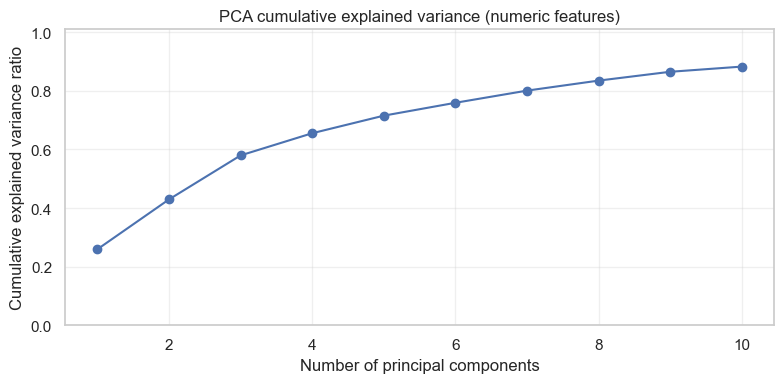

In [39]:
plt.figure(figsize=(8, 4))
components = np.arange(1, pca_components + 1)
plt.plot(components, np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('PCA cumulative explained variance (numeric features)')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance ratio')
plt.grid(alpha=0.3)
plt.ylim(0, 1.01)
plt.tight_layout()


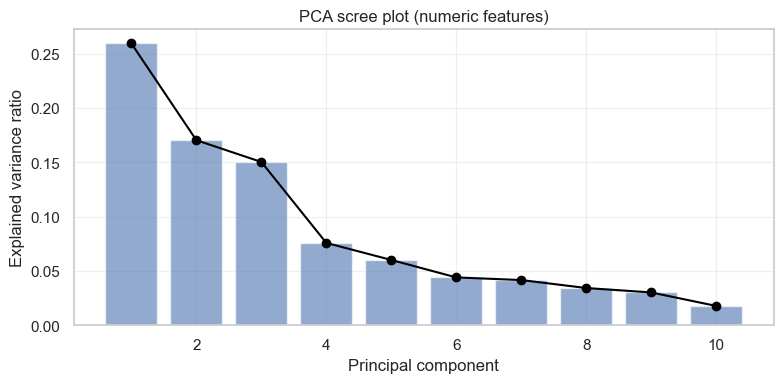

In [40]:
plt.figure(figsize=(8, 4))
components = np.arange(1, pca_components + 1)
plt.bar(components, pca.explained_variance_ratio_, alpha=0.6, label='Individual variance')
plt.plot(components, pca.explained_variance_ratio_, marker='o', color='black')
plt.title('PCA scree plot (numeric features)')
plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.grid(alpha=0.3)
plt.tight_layout()


## Summary Analysis

This exploratory data analysis examined futures trading data for ES (S&P 500) and NQ (Nasdaq 100) contracts, focusing on feature relationships, data quality, and preprocessing for predictive modeling.

### Key Findings

**Data Overview:**
- Dataset contains 13,007 observations across 2 tickers (ES and NQ) with 60+ features
- No missing values in core features; missingness only appears in engineered target columns at dataset boundaries
- Zero duplicated rows, high data quality

**Feature Characteristics:**
- **Price variables** (open, high, low, close) exhibit strong positive correlations (>0.95), confirming they move together
- **Technical indicators** show varying correlation strengths, with some pairs exceeding 0.8 absolute correlation
- **Target variable** (daily returns) is centered near zero with balanced positive/negative outcomes, suggesting no systematic bias

**Class Balance:**
- `prev_return_D_is_bullish` flag shows near-perfect balance between bull/bear days (ratio ~1.05)
- No resampling or class weighting required for classification tasks

**Multicollinearity Issues:**
- Identified numerous highly correlated feature pairs (>0.8), particularly among:
  - Price-related variables (open/high/low/close)
  - Long-horizon moving averages
- This multicollinearity justifies dimensionality reduction approaches

**Ticker Behavior:**
- ES and NQ show similar distributional patterns in the pairplot
- Both tickers show comparable return characteristics
- No obvious ticker-specific patterns that would require separate modeling

### Preprocessing Pipeline

**Feature Engineering:**
- Created 18 multi-day target columns (2-19 day forward returns) for various prediction horizons

**Transformation Strategy:**
- **Numeric features** (43 features): Median imputation + standardization (z-score normalization)
- **Categorical features** (2 features): Most-frequent imputation + one-hot encoding
- Combined pipeline produces sparse matrix with 37,249 columns (due to one-hot encoding explosion)

**Dimensionality Reduction:**
1. **TruncatedSVD (30 components):** 
   - Applied to full sparse matrix (numeric + categorical)
   - Captures 92% of total variance
   - Reduces 37K+ features to 30 dimensions
   - Efficient for sparse data

2. **PCA (10 components):**
   - Applied separately to numeric features only
   - Captures 88% of numeric feature variance
   - Helps interpret which original features drive variation
   - More interpretable than SVD for understanding feature importance

### Potential Challenges with this Dataset

1. **High Multicollinearity**
    - Open/high/low/close are 95%+ correlated
    - Linear models will struggle; coefficients would be unstable

2. **Non-Stationary**
    - Price levels change over time (market grows)
    - What work in the past (e.g. 2010) may not work for current/future (e.g. 2020, 2025)
    - Models trained on old data may fail on new data

3. **Potential Look-Ahead Bias**
    - Risk of data leakage if not careful with train/test split
    - Use time-based split (walk-forward validation) instead of random shuffling